# Подготовка

In [2]:
IN_GOOGLE_COLAB = get_ipython().__class__.__module__.startswith('google.colab') # type: ignore #
print(f"{IN_GOOGLE_COLAB=}")

IN_GOOGLE_COLAB=True


In [3]:
if not IN_GOOGLE_COLAB:
    !CHCP 65001

## Распаковка архивов

In [11]:
if IN_GOOGLE_COLAB:
    import zipfile
    import os

    # Путь к ZIP-архиву
    zip_path = "/content/dactyl-recognition-main.zip"
    extract_path = "/content/"

    # Распаковываем
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    # Исходная папка после распаковки
    source_folder = "/content/dactyl-recognition-main/HandReader"

    # Проверяем, что папка существует
    if os.path.exists(source_folder):
        # Перемещаем HandReader в /content/handreader
        !mv "{source_folder}" /content/handreader
        print("✅ HandReader перемещён в /content/handreader")

        # Удаляем пустую родительскую папку
        !rm -rf /content/dactyl-recognition-main
        print("✅ Временная папка удалена")
    else:
        print(f"❌ Папка {source_folder} не найдена!")
        print("\nСодержимое распакованного:")
        !ls -la /content/dactyl-recognition-main/

    # Переходим в папку проекта
    %cd /content/handreader

    # Проверяем структуру
    print("\n📁 Содержимое /content/handreader:")
    !ls -la

    print("\n📁 Содержимое configs:")
    !ls configs/ 2>/dev/null || echo "❌ configs не найдена"

    print("\n📁 Содержимое src/models:")
    !ls src/models/ 2>/dev/null || echo "❌ src/models не найдена"

mv: cannot move '/content/dactyl-recognition-main/HandReader' to '/content/handreader/HandReader': Directory not empty
✅ HandReader перемещён в /content/handreader
✅ Временная папка удалена
/content/handreader

📁 Содержимое /content/handreader:
total 64
drwxr-xr-x 10 root root 4096 Apr 21 22:20  .
drwxr-xr-x  1 root root 4096 Apr 21 22:56  ..
-rw-r--r--  1 root root  101 Apr 21 22:14 '=4.14.1'
drwxr-xr-x  4 root root 4096 Apr 21 21:54  configs
drwxr-xr-x  2 root root 4096 Apr 21 21:54  data
drwxr-xr-x  3 root root 4096 Apr 21 22:25  demo_KP
drwxr-xr-x  8 root root 4096 Apr 21 22:20  HandReader
-rw-r--r--  1 root root 3320 Apr 21 21:54  KP_reqs.txt
-rw-r--r--  1 root root 2229 Apr 21 21:54  .pre-commit-config.yaml
-rw-r--r--  1 root root    0 Apr 21 21:54  .project-root
-rw-r--r--  1 root root  461 Apr 21 21:54  pyproject.toml
-rw-r--r--  1 root root 3110 Apr 21 21:54  README.md
-rw-r--r--  1 root root 2374 Apr 21 21:54  RGB_KP_reqs.txt
drwxr-xr-x  3 root root 4096 Apr 21 21:54  scripts

In [12]:
if IN_GOOGLE_COLAB:
  import os

  file_path = "/content/HandReader_Znaki.zip"

  if os.path.exists(file_path):
      # Проверяем размер
      size_mb = os.path.getsize(file_path) / (1024 * 1024)
      print(f"Размер файла: {size_mb:.2f} MB")

      # Смотрим первые байты (определяем тип файла)
      with open(file_path, 'rb') as f:
          header = f.read(10)
      print(f"Заголовок файла: {header}")

      # Если это папка, а не zip
      if os.path.isdir(file_path):
          print("Это папка, а не ZIP!")
          !ls -la "{file_path}"
  else:
      print("Файл не найден")

Размер файла: 431.64 MB
Заголовок файла: b'PK\x03\x04\x14\x00\x00\x00\x00\x00'


In [13]:
if IN_GOOGLE_COLAB:
    # Путь к ZIP с весами (загрузите его тоже через панель Файлы)
    weights_zip = "/content/HandReader_Znaki.zip"

    if os.path.exists(weights_zip):
        with zipfile.ZipFile(weights_zip, 'r') as zip_ref:
            zip_ref.extractall("/content/handreader/weights")
        print("✅ Веса распакованы")
    else:
        print("❌ HandReader_Znaki.zip не найден. Загрузите его в /content/")

✅ Веса распакованы


## Определение путей

In [4]:
import os
from pathlib import Path
if IN_GOOGLE_COLAB:
    HANDREADER_ROOT = Path(os.path.join("content", "handreader"))
else:
    HANDREADER_ROOT = Path("HandReader")
WEIGHTS_FOLDER = Path("weights") / "znaki"

In [28]:
%pip install -q pickleshare

In [5]:
%cd {HANDREADER_ROOT}

[Errno 2] No such file or directory: 'content/handreader'
/content


In [6]:
# Проверяем структуру
print("\n📁 Содержимое /content/handreader:")
print(*os.listdir())

print("\n📁 Содержимое configs:")
try:
    print(*os.listdir("configs"))
except:
    print("❌ configs не найдена")

print("\n📁 Содержимое src/models:")
try:
    print(*os.listdir(os.path.join("src", "models")))
except:
    print("❌ src/models не найдена")

print("\n📁 Структура весов:")
try:
    print(*os.listdir(WEIGHTS_FOLDER))
except:
    print(f"❌ {WEIGHTS_FOLDER} не найдена")


📁 Содержимое /content/handreader:
.config drive dactyl-recognition-main.zip handreader HandReader_Znaki.zip sample_data

📁 Содержимое configs:
❌ configs не найдена

📁 Содержимое src/models:
❌ src/models не найдена

📁 Структура весов:
❌ weights/znaki не найдена


## Установка библиотек (после которой колаб просит перезагрузить систему)
!!! Требуется `Python 3.9` (но можете попробовать питон выше, вдруг получится)  
!!! При _локальном_ запуске используйте виртуальную среду (`venv`, `conda` и т.п.)  

In [14]:
# ЯЧЕЙКА 3.5: Фикс NumPy (обязательно!)
import numpy as np
print(f"Текущая версия NumPy: {np.__version__}")

# Если версия 2.x, понижаем до 1.26.4
if np.__version__ >= "2.0.0":
    !pip install -q numpy==1.26.4
    print("✅ NumPy понижен до 1.26.4. ПЕРЕЗАПУСТИТЕ СРЕДУ!")
else:
    print("✅ NumPy уже 1.x, всё хорошо")

Текущая версия NumPy: 1.26.4
✅ NumPy уже 1.x, всё хорошо


# проверим версию PyTorch и NumPy

In [7]:
import torch
import numpy as np

# ============================================================
# 1. ПРОВЕРКА PyTorch
# ============================================================
print(f"PyTorch версия: {torch.__version__}")
print(f"CUDA доступна: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("❌ GPU не обнаружен — обучение/инференс будут медленными")

# ============================================================
# 2. ПРОВЕРКА NumPy
# ============================================================
print(f"\nТекущая версия NumPy: {np.__version__}")

if np.__version__ >= "2.0.0":
    print("⚠️ Обнаружен NumPy 2.x — могут быть конфликты с PyTorch 2.2.0")
else:
    print("✅ NumPy версии 1.x — совместимость с PyTorch обеспечена")

# Проверяем, не сломан ли numpy.random (частый баг в Colab)
try:
    from numpy.random import RandomState
    print("✅ Модуль numpy.random работает корректно")
except ImportError as e:
    print(f"⚠️ Проблема с numpy.random: {e}")

# ============================================================
# 3. ИТОГ
# ============================================================
if torch.cuda.is_available() and np.__version__ < "2.0.0":
    print("\n✅ Среда полностью готова! Можно запускать загрузку модели.")
else:
    print("\n⚠️ Есть проблемы, но можно продолжать (используем CPU и/или NumPy 2.x)")

PyTorch версия: 2.2.0+cu118
CUDA доступна: True
GPU: Tesla T4

Текущая версия NumPy: 1.26.4
✅ NumPy версии 1.x — совместимость с PyTorch обеспечена
✅ Модуль numpy.random работает корректно

✅ Среда полностью готова! Можно запускать загрузку модели.


In [33]:
if IN_GOOGLE_COLAB:
    print("Установка для Google Colab")
    %pip install typing_extensions>=4.14.1
    %pip install torch==2.2.0 torchvision==0.17.0 --index-url https://download.pytorch.org/whl/cu118
    %pip install pyturbojpeg
    %pip install -r RGB_KP_reqs.txt
else:
    print("Локальная установка")
    %pip install torch==2.0.1 torchvision==0.15.2 --index-url https://download.pytorch.org/whl/cu118
    %pip install pyturbojpeg==1.7.7
    %pip install -r RGB_KP_reqs.txt

Установка для Google Colab
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.7/811.7 MB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 24.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 94.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 83.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 126.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.5/728.5 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 18.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━

  Preparing metadata (setup.py) ... done
  Created wheel for pyturbojpeg: filename=PyTurboJPEG-2.2.0-py3-none-any.whl size=18919 sha256=4c4657df68b0be42a87d12509dea888b936f97b53b1213f1c22abf1c6cc75973
  Stored in directory: /root/.cache/pip/wheels/43/0e/d9/82122e9f38068a1c2603e8fdb639f87df56cc4d8dc50eef92e
Successfully built pyturbojpeg
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 13.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.2/162.2 kB 21.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 23.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
^C


#доп для препроцесса KP

In [ ]:
!pip uninstall -y mediapipe
!pip install mediapipe==0.10.11

print("✅ MediaPipe 0.10.11 установлен! Перезапустите среду (Runtime → Restart runtime)")

Found existing installation: mediapipe 0.10.33
Uninstalling mediapipe-0.10.33:
  Successfully uninstalled mediapipe-0.10.33
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 24.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.2 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
ydf 0.12.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.


✅ MediaPipe 0.10.11 установлен! Перезапустите среду (Runtime → Restart runtime)


# Импорт модели

In [9]:
# Установка всех зависимостей HandReader
!pip install -q rootutils pyrootutils rapidfuzz omegaconf hydra-core pytorch-lightning wandb tensorboard

print("✅ Зависимости установлены!")

✅ Зависимости установлены!


In [51]:
import torch
from pathlib import Path

# ============================================================
# ВЫБОР РЕЖИМА (измените здесь при необходимости)
# ============================================================
MODE = "RGB_KP"  # Варианты: "RGB", "KP", "RGB_KP"

# Путь к папке с весами (у вас уже определён?)
WEIGHTS_FOLDER = Path("/content/handreader/weights/znaki")

print(f"📦 Режим: {MODE}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

# ============================================================
# ЗАГРУЗКА МОДЕЛИ В ЗАВИСИМОСТИ ОТ РЕЖИМА
# ============================================================

if MODE == "RGB":
    from src.models.RGB.models import TSM_Resnet
    from src.models.modules.head import RNNHead

    decoder_net = RNNHead(
        input_dim=1024,
        hidden_dim=1024,
        num_layers=2,
        num_classes=35,
        bidirectional=True,
        return_outs=False
    )

    model = TSM_Resnet(
        encoder='resnet34',
        decoder=None,
        num_classes=35,
        decoder_net=decoder_net,
        unidirection=False
    )

    checkpoint_path = WEIGHTS_FOLDER / "rgb" / "best.pt"

    class Extractor(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.backbone = model.backbone

        def forward(self, rgb, lengths):
            """rgb: [T, 3, 224, 224], lengths: torch.Tensor([T])"""
            assert isinstance(lengths, torch.Tensor), "lengths должен быть тензором!"
            return self.backbone(rgb.cuda(), lengths.cuda())

    print("✅ RGB модель создана")

elif MODE == "KP":
    from src.models.KP.models import MLP_LSTM_FE
    from src.models.modules import MLP, FeatureMapExtractorModel
    from src.models.modules.head import RNNHead

    # Параметры ИЗ КОНФИГА kp_Znaki.yaml
    fe = FeatureMapExtractorModel(
        num_keypoints=54,
        out_dim=144
    )

    mlp = MLP(
        input_dim=144,
        hidden_dim=512,      # ← было 512, так и оставляем
        output_dim=512,      # ← ВАЖНО! Было 1024, стало 512
        double_conv=False    # ← в конфиге не указан, пробуем False
    )

    decoder_net = RNNHead(
        input_dim=512,       # ← ВАЖНО! Было 1024, стало 512
        hidden_dim=512,
        num_layers=2,
        num_classes=35,
        bidirectional=True,
        return_outs=False
    )

    model = MLP_LSTM_FE(
        mlp=mlp,
        decoder=decoder_net,  # ← в конфиге называется decoder
        fe=fe
    )

    checkpoint_path = WEIGHTS_FOLDER / "kp" / "best.pt"

    class Extractor(torch.nn.Module):
      def __init__(self, model):
          super().__init__()
          self.model = model

      def forward(self, kp, lengths):
          """
          Возвращает ЭМБЕДДИНГИ (выход MLP), а не логиты декодера
          kp: [1, T, 54, 3]
          """
          # Пропускаем через feature extractor и MLP, но НЕ через decoder
          x = self.model.fe(kp.cuda())      # FeatureMapExtractorModel
          x = self.model.mlp(x)             # MLP → [1, T, 512]
          return x

    print("✅ KP модель создана (параметры из kp_Znaki.yaml)")

elif MODE == "RGB_KP":
    from src.models.KP_RGB.models import JointEncoders, TSM_Resnet_Encoder, MLP_FE, MLP
    from src.models.modules import FeatureMapExtractorModel
    from src.models.modules.head import RNNHead

    encoder_rgb = TSM_Resnet_Encoder(
        encoder='resnet34',
        unidirection=False
    )

    fe = FeatureMapExtractorModel(
        num_keypoints=54,
        out_dim=144
    )

    mlp = MLP(
        input_dim=144,
        hidden_dim=512,
        output_dim=1024,
        double_conv=True
    )

    encoder_kp = MLP_FE(mlp=mlp, fe=fe)

    decoder_net = RNNHead(
        input_dim=1024,
        hidden_dim=1024,
        num_layers=2,
        num_classes=35,
        bidirectional=True,
        return_outs=False
    )

    model = JointEncoders(
        encoder_rgb=encoder_rgb,
        encoder_kp=encoder_kp,
        decoder=None,
        decoder_net=decoder_net,
        reduction='sum'
    )

    checkpoint_path = WEIGHTS_FOLDER / "kp_rgb" / "best.pt"

    class Extractor(torch.nn.Module):
      def __init__(self, model):
          super().__init__()
          self.model = model

      def forward(self, rgb, kp, lengths):
          """
          Возвращает ЭМБЕДДИНГИ (сумму RGB и KP энкодеров), а не логиты
          """
          x_rgb = self.model.encoder_rgb(rgb.cuda(), lengths.cuda())
          x_kp = self.model.encoder_kp(kp.cuda())
          return x_rgb + x_kp  # [1, T, 1024]

    print("✅ RGB_KP модель создана")

else:
    raise ValueError(f"Неизвестный MODE: {MODE}")

# ============================================================
# ЗАГРУЗКА ВЕСОВ
# ============================================================

checkpoint = torch.load(checkpoint_path, map_location='cuda', weights_only=False)
state_dict = checkpoint['state_dict'] if 'state_dict' in checkpoint else checkpoint

# Убираем префикс 'model.' если есть
new_state_dict = {}
for k, v in state_dict.items():
    new_key = k.replace('model.', '')
    new_state_dict[new_key] = v

model.load_state_dict(new_state_dict, strict=False)
model = model.cuda().eval()

extractor = Extractor(model)

print(f"✅ Модель {MODE} загружена на GPU!")

# ============================================================
# ТЕСТОВЫЙ ПРОГОН
# ============================================================

print(f"\n🎯 Тест {MODE} модели:\n")

for length in [8, 16, 32]:
    lengths = torch.tensor([length]).cuda()

    with torch.no_grad():
        if MODE == "RGB":
            dummy_rgb = torch.randn(length, 3, 224, 224).cuda()
            emb = extractor(dummy_rgb, lengths)
        elif MODE == "KP":
          # Правильный формат: [B, T, V, C] = [1, length, 54, 3]
          dummy_kp = torch.randn(1, length, 54, 3).cuda()
          emb = extractor(dummy_kp, lengths)
        elif MODE == "RGB_KP":
          # RGB: [T, 3, 224, 224]
          dummy_rgb = torch.randn(length, 3, 224, 224).cuda()
          # KP: [1, T, 54, 3] — такой же формат, как в чистой KP
          dummy_kp = torch.randn(1, length, 54, 3).cuda()
          emb = extractor(dummy_rgb, dummy_kp, lengths)

    print(f"   Видео из {length:2d} кадров → эмбеддинги: {emb.shape}")

print(f"\n✅ Каждый кадр даёт вектор из {emb.shape[-1]} признаков")
print("\n✅ ВСЁ РАБОТАЕТ!")

📦 Режим: RGB_KP
PyTorch: 2.2.0+cu118
CUDA: True
start FeatureExtracter 23:21:49


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


end FeatureExtracter 23:21:50
✅ RGB_KP модель создана
✅ Модель RGB_KP загружена на GPU!

🎯 Тест RGB_KP модели:

   Видео из  8 кадров → эмбеддинги: torch.Size([1, 8, 1024])


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/instancenorm.py:80: UserWarning: input's size at dim=1 does not match num_features. You can silence this warning by not passing in num_features, which is not used because affine=False
  warnings.warn(f"input's size at dim={feature_dim} does not match num_features. "


   Видео из 16 кадров → эмбеддинги: torch.Size([1, 16, 1024])
   Видео из 32 кадров → эмбеддинги: torch.Size([1, 32, 1024])

✅ Каждый кадр даёт вектор из 1024 признаков

✅ ВСЁ РАБОТАЕТ!


In [16]:
# Смотрим, как загружаются landmarks
!cat /content/handreader/src/data/KP_RGB/dataset_rdl.py | grep -A 20 "landmarks"

    A PyTorch dataset class for joint RGB and landmarks-based sequence learning tasks.

    This class represents a dataset where each sample consists of RGB frames and corresponding landmarks
    (such as keypoints) that can be used for a variety of tasks like pose estimation, action recognition,
    or sequence classification. The dataset supports various transformations such as temporal rescaling,
    random rotations, and horizontal flips.

    Parameters
    ----------
    path_to_rgb : str
        Path to the directory containing RGB frame sequences in HDF5 format.

    path_to_landmarks : str
        Path to the directory containing landmarks (e.g., keypoints) in `.npy` format.

    df : pandas.DataFrame
        DataFrame containing metadata for the dataset, including file paths and corresponding processed labels.

    transforms : callable
        A transformation pipeline to apply to each image sample, typically from a library like `albumentations`.

    partition : str
      

# Подгрузка видео

In [17]:
from pathlib import Path

if IN_GOOGLE_COLAB:
    # Подключение к Google Диску
    from google.colab import drive
    drive.mount('/content/drive')

    BASE_PATH = Path("/content/drive/MyDrive") # "Мой диск" на Гугл-диске

    # ПУТЬ К ВАШЕЙ ПАПКЕ на Гугл-диске - ИЗМЕНИТЕ ЭТО!
    # По умолчанию: /content/drive/MyDrive/DactDetect
    FOLDER_PATH = BASE_PATH / "DactDetect"  # <- измените если нужно
    # Видео будут доступны по пути:
    # /content/drive/MyDrive/путь_к_видео/
else:
    # Локальная работа
    BASE_PATH = Path("..") # Корень нашего репозитория

    # ПУТЬ К ВАШЕЙ ПАПКЕ локально относительно корня репозитория - ИЗМЕНИТЕ ЭТО!
    # .. = подняться ещё на папку выше
    FOLDER_PATH = BASE_PATH / ".." / "extracted_corpus"

print(FOLDER_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/DactDetect


In [18]:
# Укажите путь к папке DactDetect и проверим содержимое
import os

print(f"📁 Проверяем папку: {FOLDER_PATH}")

if os.path.exists(FOLDER_PATH):
    print("✅ Папка найдена!")

    # Показываем ВСЁ содержимое папки
    files = os.listdir(FOLDER_PATH)
    print(f"\n📋 ВСЕ файлы в папке ({len(files)} шт.):")

    # Сортируем по типу
    excel_files = []
    video_files = []
    other_files = []

    for f in files:
        if f.endswith(('.xlsx', '.xls')):
            excel_files.append(f)
        elif f.endswith(('.webm', '.mp4', '.avi', '.mov', '.mkv')):
            video_files.append(f)
        else:
            other_files.append(f)

    print(f"\n📊 Excel файлы ({len(excel_files)}):")
    if excel_files:
        for f in excel_files:
            print(f"   ✅ {f}")
    else:
        print("   ❌ НЕТ Excel файлов!")

    print(f"\n🎬 Видео файлы ({len(video_files)}):")
    if video_files:
        for f in video_files[:10]:  # покажем первые 10
            print(f"   🎥 {f}")
        if len(video_files) > 10:
            print(f"   ... и еще {len(video_files) - 10}")
    else:
        print("   ❌ НЕТ видео файлов!")

    print(f"\n📄 Другие файлы ({len(other_files)}):")
    for f in other_files[:5]:
        print(f"   📄 {f}")

else:
    print(f"❌ Папка НЕ найдена!")
    print(f"\n🔍 Поиск возможных папок {'на диске' if IN_GOOGLE_COLAB else 'в репозитории'}:")

    # Ищем все папки с похожим названием
    assert os.path.exists(BASE_PATH), f"Корневая папка не найдена: {BASE_PATH}"
    all_folders = [f for f in os.listdir(BASE_PATH)
                    if os.path.isdir(os.path.join(BASE_PATH, f))]

    print(f"\n📁 Папки в корне:")
    dact_folders = []
    for folder in all_folders:
        for keyword in ['dact', 'жест', 'hand', 'corpus', 'model', 'extract', 'detect']:
            if keyword in folder.lower():
                dact_folders.append(folder)
                print(f"   🔍 {folder}")
                break

    if dact_folders:
        print(f"\n💡 Возможно, ваша папка одна из этих:")
        for f in dact_folders:
            print(f"   ➡️ {BASE_PATH}/{f}")
    else:
        print("   (нет папок с ключевыми словами в названии)")
        print("\n📋 Все папки в корне:")
        for f in all_folders[:10]:
            print(f"   📁 {f}")

📁 Проверяем папку: /content/drive/MyDrive/DactDetect
✅ Папка найдена!

📋 ВСЕ файлы в папке (907 шт.):

📊 Excel файлы (1):
   ✅ Расшифровки видео.xlsx

🎬 Видео файлы (903):
   🎥 RSLN-n2-s2_01_стюардесса.webm
   🎥 RSLN-n4-s2_01_чай.webm
   🎥 RSLN-n4-s2_02_чай.webm
   🎥 RSLN-n4-s2_03_телеграмма.webm
   🎥 RSLN-n4-s2_04_регистрацию.webm
   🎥 RSLN-n4-s2_05_справочная.webm
   🎥 RSLN-n4-s2_06_рейс.webm
   🎥 RSLN-n4-s2_07_час.webm
   🎥 RSLN-n4-s2_08_час.webm
   🎥 RSLN-n4-s2_09_рейс.webm
   ... и еще 893

📄 Другие файлы (3):
   📄 файл (File responses)
   📄 fingerspelling_dataset_from_channel_ni_dnya_bez_daktilya
   📄 Расшифровки видео.gsheet


In [19]:
# ТАБЛИЦА С РАСШИФРОВКАМИ - ИЗМЕНИТЕ ПОД СЕБЯ
#SPREADSHEET_FILE = "values.xlsx"
SPREADSHEET_FILE = "Расшифровки видео.xlsx"
assert os.path.exists(FOLDER_PATH / SPREADSHEET_FILE), "Таблица не существует"

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
%pip install openpyxl

# читаем Расшифровки видео.xlsx без pandas и numpy

In [22]:
import openpyxl
import os

# === ЗАГРУЗКА EXCEL БЕЗ PANDAS ===
excel_file = FOLDER_PATH / SPREADSHEET_FILE
assert os.path.exists(excel_file), "Таблица не существует"

print(f"\n🔄 Читаем файл: {excel_file}")

# Открываем книгу
wb = openpyxl.load_workbook(excel_file, data_only=True)
print(f"📑 Доступные листы: {wb.sheetnames}")

# Выбираем лист
if 'Корпус' in wb.sheetnames:
    ws = wb['Корпус']
    print(f"✅ Загружен лист 'Корпус'")
else:
    ws = wb.active
    print(f"⚠️ Использую активный лист: {ws.title}")

# Извлекаем данные в список словарей
data = []
headers = None

for i, row in enumerate(ws.iter_rows(values_only=True)):
    if i == 0:
        headers = [str(cell) if cell is not None else f"Unnamed_{j}" for j, cell in enumerate(row)]
    else:
        if any(cell is not None for cell in row):
            data.append(dict(zip(headers, row)))

print(f"✅ Загружено {len(data)} записей")

# === ПРОСТАЯ СТРУКТУРА ДЛЯ ДАЛЬНЕЙШЕЙ РАБОТЫ ===
# Создаём легковесный объект, совместимый с вашим существующим кодом
class SimpleDataFrame:
    def __init__(self, data, headers):
        self.data = data
        self.columns = headers
        self._index = 0

    def __len__(self):
        return len(self.data)

    def head(self, n=5):
        return self.data[:n]

    def iterrows(self):
        for i, row in enumerate(self.data):
            yield i, SimpleRow(row)

    def __getitem__(self, col):
        return [row.get(col) for row in self.data]

class SimpleRow:
    def __init__(self, row_dict):
        self._row = row_dict
    def __getitem__(self, key):
        return self._row.get(key)

# Создаём наш "DataFrame"
df = SimpleDataFrame(data, headers)

print(f"\n📋 Первые 5 строк:")
for i, row in enumerate(df.head()):
    print(f"   {i}: {list(row.values())[:5]}...")

print(f"\n📊 Колонки таблицы ({len(df.columns)}):")
for i, col in enumerate(df.columns):
    print(f"   {i+1}. '{col}'")

# Определяем колонки для видео и слов (как в вашем старом коде)
possible_file_cols = ['файл', 'file', 'filename', 'video', 'видео']
possible_word_cols = ['расшифровка', 'word', 'text', 'слово', 'значение']

file_column = None
for col in possible_file_cols:
    if col in df.columns:
        file_column = col
        break

word_column = None
for col in possible_word_cols:
    if col in df.columns:
        word_column = col
        break

print(f"\n✅ Колонка с файлами: '{file_column}'")
print(f"✅ Колонка со словами: '{word_column}'")

# === СОЗДАЁМ found_videos (как в вашем старом коде) ===
found_videos = []
missing_videos = []

for idx, row in df.iterrows():
    filename = str(row[file_column]) if file_column else None
    if not filename or filename == 'None':
        continue

    filename = filename.strip()
    video_path = os.path.join(FOLDER_PATH, filename)

    if os.path.exists(video_path):
        word = str(row[word_column]) if word_column and row[word_column] else "unknown"
        found_videos.append({
            'filename': filename,
            'path': video_path,
            'word': word,
            'index': idx
        })
    else:
        missing_videos.append(filename)

print(f"\n📊 Результаты:")
print(f"   ✅ Найдено видео: {len(found_videos)}")
print(f"   ❌ Отсутствует: {len(missing_videos)}")

if found_videos:
    print(f"\n✅ Первые 5 найденных:")
    for v in found_videos[:5]:
        print(f"   ✓ {v['filename']} -> {v['word']}")

# Сохраняем found_videos (это всё, что нужно для дальнейшей работы!)
%store found_videos

print("\n✅ Готово! found_videos сохранён.")


🔄 Читаем файл: /content/drive/MyDrive/DactDetect/Расшифровки видео.xlsx
📑 Доступные листы: ['Форма', 'Корпус', 'Канал', 'Метаданные']
✅ Загружен лист 'Корпус'
✅ Загружено 903 записей

📋 Первые 5 строк:
   0: ['RSLN-n1-s1_01_раз.webm', 'раз', 'RSLN-n1-s1', 's1']...
   1: ['RSLN-n2-s1_01_суши.webm', 'суши', 'RSLN-n2-s1', 's1']...
   2: ['RSLN-n2-s1_02_был.webm', 'был', 'RSLN-n2-s1', 's1']...
   3: ['RSLN-n2-s2_01_стюардесса.webm', 'стюардесса', 'RSLN-n2-s2', 's2']...
   4: ['RSLN-n4-s2_01_чай.webm', 'чай', 'RSLN-n4-s2', 's2']...

📊 Колонки таблицы (4):
   1. 'файл'
   2. 'расшифровка'
   3. 'текст'
   4. 'информант'

✅ Колонка с файлами: 'файл'
✅ Колонка со словами: 'расшифровка'

📊 Результаты:
   ✅ Найдено видео: 903
   ❌ Отсутствует: 0

✅ Первые 5 найденных:
   ✓ RSLN-n1-s1_01_раз.webm -> раз
   ✓ RSLN-n2-s1_01_суши.webm -> суши
   ✓ RSLN-n2-s1_02_был.webm -> был
   ✓ RSLN-n2-s2_01_стюардесса.webm -> стюардесса
   ✓ RSLN-n4-s2_01_чай.webm -> чай
Stored 'found_videos' (list)

✅ Готово!

# Функции для опробования моделей

In [23]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from typing import List, Union

# Нормализация ImageNet

NORM_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
NORM_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess_frames(video_path, img_size=224):
    """
    Возвращает предобработанный список кадров видео
    """
    cap = cv2.VideoCapture(video_path)
    frames: list[np.ndarray] = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # BGR -> RGB
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        # Resize
        frame = cv2.resize(frame, (img_size, img_size))
        # Нормализация
        frame = frame.astype(np.float32) / 255.0
        frame = (frame - NORM_MEAN) / NORM_STD
        # HWC -> CHW
        frame = np.transpose(frame, (2, 0, 1))
        frames.append(frame)

    cap.release()

    return frames


def display_frames(frames: Union[np.ndarray, List], title: str = "Кадры видео"):
    if isinstance(frames, np.ndarray) and len(frames.shape) == 2:
        frames = [frames]
    cols = 5 if len(frames) > 12 else 4 if len(frames) > 4 else len(frames)
    rows = len(frames) // cols
    fig, axs = plt.subplots(rows, cols, figsize=(2*cols, 2*rows), squeeze=False)
    for ax, f in zip(axs.flatten(), frames):
        ax: Axes
        f = np.transpose(f * NORM_STD[:, None, None] + NORM_MEAN[:, None, None], (1, 2, 0))
        ax.imshow(f)
        ax.set_axis_off()
    fig.tight_layout()
    fig.suptitle(title)
    plt.show()


def apply_model_full(frames, model):
    """
    Применяет модель для ВСЕХ кадров видео (правильный TSAM!)
    """
    actual_length = len(frames)
    if actual_length == 0:
        return None, 0, False

    # Исправление: сначала в тензор, потом на GPU
    stacked = np.stack(frames)
    if torch.cuda.is_available():
        video_tensor = torch.from_numpy(stacked).cuda()
    else:
        video_tensor = torch.from_numpy(stacked)

    with torch.no_grad():
        embeddings: torch.Tensor = model(video_tensor, torch.tensor([actual_length]))

    return embeddings.squeeze(0).cpu().numpy(), actual_length, True

print("✅ Функция apply_model_full загружена!")

✅ Функция apply_model_full загружена!


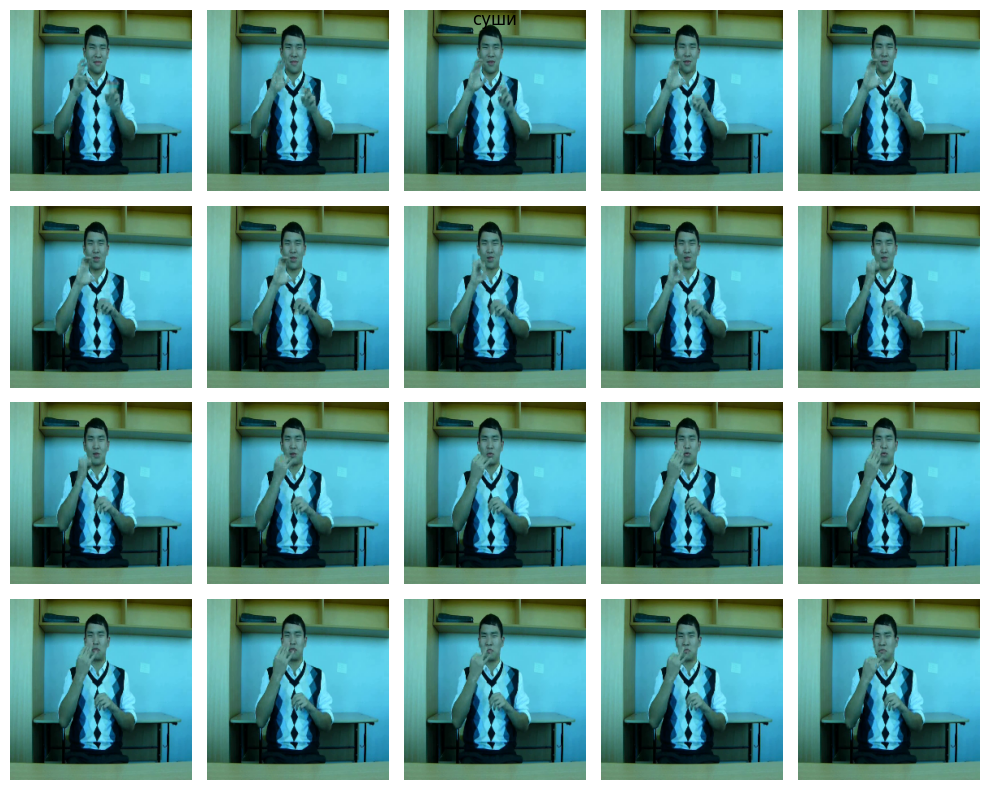

In [24]:
video_info = found_videos[1]
frames = preprocess_frames(video_info['path'])
length = len(frames)
display_frames(frames[length//2 - 10 : length//2 + 10], video_info['word'])

# Препроцесс для KP и RGB_KP

In [41]:
# ЯЧЕЙКА 5.5: KP-препроцессор (эталонный подход HandReader)
# Запускайте только если MODE = "KP" или "RGB_KP"

if MODE in ["KP", "RGB_KP"]:
    import mediapipe as mp
    import json
    import cv2
    import numpy as np

    # 1. Загрузка конфига нужных точек
    with open('/content/handreader/data/inference_args.json') as f:
        ALL_COLUMNS = json.load(f)['selected_columns']

    # 2. Фильтруем только hand + pose (как в эталонном даталоадере)
    FILTERED_COLUMNS = [
        col for col in ALL_COLUMNS
        if any(s in col for s in ['hand', 'pose'])
    ]

    # 3. Парсим названия точек
    def parse_kp_name(name):
        """x_left_hand_5 -> ('left_hand', 5)"""
        parts = name.split('_', 1)
        if len(parts) < 2:
            return None, None
        ltype = parts[1].rsplit('_', 1)[0]
        idx = int(parts[1].rsplit('_', 1)[1])
        return ltype, idx

    # 4. Определяем порядок точек (как в FILTERED_COLUMNS)
    LANDMARK_ORDER = []
    for col in FILTERED_COLUMNS:
        if col.startswith('x_'):
            ltype, idx = parse_kp_name(col)
            LANDMARK_ORDER.append((ltype, idx))

    NUM_KEYPOINTS = len(LANDMARK_ORDER)
    print(f"✅ KP настроены: {NUM_KEYPOINTS} точек")

    # 5. MediaPipe (один раз)
    mp_holistic = mp.solutions.holistic
    holistic = mp_holistic.Holistic(
        static_image_mode=True,
        model_complexity=2,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    )

    # 6. Класс препроцессора
    class KPPreprocessor:
        def __init__(self):
            self.landmark_order = LANDMARK_ORDER
            self.num_keypoints = NUM_KEYPOINTS

        def extract_landmarks(self, frame_rgb):
            results = holistic.process(frame_rgb)

            left_hand = {}
            if results.left_hand_landmarks:
                for i, lm in enumerate(results.left_hand_landmarks.landmark):
                    left_hand[i] = (lm.x, lm.y, lm.z)

            right_hand = {}
            if results.right_hand_landmarks:
                for i, lm in enumerate(results.right_hand_landmarks.landmark):
                    right_hand[i] = (lm.x, lm.y, lm.z)

            pose = {}
            if results.pose_landmarks:
                for i, lm in enumerate(results.pose_landmarks.landmark):
                    pose[i] = (lm.x, lm.y, lm.z)

            landmarks = []
            for ltype, idx in self.landmark_order:
                if ltype == 'left_hand':
                    lm = left_hand.get(idx, (0.0, 0.0, 0.0))
                elif ltype == 'right_hand':
                    lm = right_hand.get(idx, (0.0, 0.0, 0.0))
                elif ltype == 'pose':
                    lm = pose.get(idx, (0.0, 0.0, 0.0))
                else:
                    lm = (0.0, 0.0, 0.0)
                landmarks.extend(lm)

            return np.array(landmarks, dtype=np.float32)

        def normalize(self, kp_sequence):
            x = kp_sequence.reshape(-1, self.num_keypoints, 3)
            mask = x != 0
            if mask.sum() > 0:
                mean = x[mask].mean()
                std = x[mask].std()
                if std > 0:
                    x = (x - mean) / std
            x = np.where(mask, x, 0.0)
            return x.reshape(-1, self.num_keypoints * 3)

        def process_video(self, video_path):
          cap = cv2.VideoCapture(video_path)
          all_landmarks = []

          while True:
              ret, frame = cap.read()
              if not ret:
                  break
              frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
              landmarks = self.extract_landmarks(frame_rgb)
              all_landmarks.append(landmarks)

          cap.release()
          if not all_landmarks:
              return None, False

          kp_array = np.stack(all_landmarks)  # [T, 162]
          kp_norm = self.normalize(kp_array)  # [T, 162]

          # Решейпим в [1, T, 54, 3] — БАТЧ, ВРЕМЯ, ТОЧКИ, КАНАЛЫ
          kp_reshaped = kp_norm.reshape(-1, self.num_keypoints, 3)  # [T, 54, 3]
          kp_reshaped = np.expand_dims(kp_reshaped, 0)              # [1, T, 54, 3]

          return kp_reshaped, True

    # 7. Создаём экземпляр
    kp_preprocessor = KPPreprocessor()
    print("✅ KPPreprocessor готов к работе!")

else:
    kp_preprocessor = None
    print("ℹ️ KP не используется (MODE =", MODE, ")")

✅ KP настроены: 54 точек
✅ KPPreprocessor готов к работе!


# Извлечение эмбеддингов из видео


In [52]:
from tqdm import tqdm

print(f"🎯 Извлекаем {MODE} эмбеддинги для видео...\n")

all_embeddings = {}
video_data = []

for video_info in tqdm(found_videos[:5]):

    # RGB кадры (нужны для RGB и RGB_KP)
    if MODE in ["RGB", "RGB_KP"]:
        rgb_frames = preprocess_frames(video_info['path'])
        if len(rgb_frames) == 0:
            print(f"  ❌ {video_info['filename']}: нет RGB кадров")
            continue

    # KP точки (нужны для KP и RGB_KP)
    if MODE in ["KP", "RGB_KP"]:
        kp_frames, kp_success = kp_preprocessor.process_video(video_info['path'])
        if not kp_success:
            print(f"  ❌ {video_info['filename']}: нет KP точек")
            continue

    # Уравниваем длину для RGB_KP
    if MODE == "RGB_KP":
        min_len = min(len(rgb_frames), len(kp_frames))
        rgb_frames = rgb_frames[:min_len]
        kp_frames = kp_frames[:min_len]
        length = min_len
    elif MODE == "RGB":
        length = len(rgb_frames)
    elif MODE == "KP":
        length = len(kp_frames)

    # Тензоры
    if MODE == "RGB":
        rgb_tensor = torch.from_numpy(np.stack(rgb_frames)).cuda()
        with torch.no_grad():
            emb = extractor(rgb_tensor, torch.tensor([length]).cuda())
    elif MODE == "KP":
      kp_frames, ok = kp_preprocessor.process_video(video_info['path'])
      if not ok:
          print(f"  ❌ {video_info['filename']}: нет KP точек")
          continue

      # kp_frames уже [1, T, 54, 3]
      kp_tensor = torch.from_numpy(kp_frames).cuda()
      length = kp_frames.shape[1]  # T

      with torch.no_grad():
          emb = extractor(kp_tensor, torch.tensor([length]).cuda())

      emb_np = emb.squeeze(0).cpu().numpy()  # [T, 512]
    elif MODE == "RGB_KP":
      rgb_frames = preprocess_frames(video_info['path'])
      kp_frames, ok = kp_preprocessor.process_video(video_info['path'])

      if len(rgb_frames) == 0 or not ok:
          continue

      rgb_tensor = torch.from_numpy(np.stack(rgb_frames)).cuda()
      kp_tensor = torch.from_numpy(kp_frames).cuda()

      min_len = min(rgb_tensor.shape[0], kp_tensor.shape[1])
      rgb_tensor = rgb_tensor[:min_len]
      kp_tensor = kp_tensor[:, :min_len, :, :]

      with torch.no_grad():
          emb = extractor(rgb_tensor, kp_tensor, torch.tensor([min_len]).cuda())

      # === ОТЛАДКА ===
      print(f"\n🔍 Отладка для {video_info['filename']}:")
      print(f"   RGB shape: {rgb_tensor.shape}")
      print(f"   KP shape: {kp_tensor.shape}")
      print(f"   EMB shape: {emb.shape}")
      print(f"   EMB min/max: {emb.min():.3f} / {emb.max():.3f}")

      # Если размерность неправильная — смотрим, что внутри модели
      if emb.shape[-1] != 1024:
          print(f"   ⚠️ Неправильная размерность эмбеддингов: {emb.shape}")
          # Пробуем взять выход до декодера
          with torch.no_grad():
              x_rgb = extractor.model.encoder_rgb(rgb_tensor, torch.tensor([min_len]).cuda())
              x_kp = extractor.model.encoder_kp(kp_tensor)
              print(f"   encoder_rgb output: {x_rgb.shape}")
              print(f"   encoder_kp output: {x_kp.shape}")
              emb_debug = x_rgb + x_kp
              print(f"   Сумма (reduction='sum'): {emb_debug.shape}")

      length = min_len
      emb_np = emb.squeeze(0).cpu().numpy()

    all_embeddings[video_info['filename']] = {
        'embeddings': emb_np,
        'word': video_info['word'],
        'path': video_info['path'],
        'num_frames': length
    }
    video_data.append({
        'filename': video_info['filename'],
        'word': video_info['word'],
        'emb_shape': emb_np.shape,
        'num_frames': length
    })
    print(f"  ✅ {video_info['filename']}: {length} кадров")

print(f"\n✅ Успешно обработано: {len(all_embeddings)} видео")

🎯 Извлекаем RGB_KP эмбеддинги для видео...



 20%|██        | 1/5 [00:06<00:27,  6.95s/it]


🔍 Отладка для RSLN-n1-s1_01_раз.webm:
   RGB shape: torch.Size([23, 3, 224, 224])
   KP shape: torch.Size([1, 23, 54, 3])
   EMB shape: torch.Size([1, 23, 1024])
   EMB min/max: -0.077 / 3.640
  ✅ RSLN-n1-s1_01_раз.webm: 23 кадров


 40%|████      | 2/5 [00:18<00:28,  9.44s/it]


🔍 Отладка для RSLN-n2-s1_01_суши.webm:
   RGB shape: torch.Size([31, 3, 224, 224])
   KP shape: torch.Size([1, 31, 54, 3])
   EMB shape: torch.Size([1, 31, 1024])
   EMB min/max: -0.074 / 3.602
  ✅ RSLN-n2-s1_01_суши.webm: 31 кадров


...


🔍 Отладка для RSLN-n2-s1_02_был.webm:
   RGB shape: torch.Size([26, 3, 224, 224])
   KP shape: torch.Size([1, 26, 54, 3])
   EMB shape: torch.Size([1, 26, 1024])
   EMB min/max: -0.073 / 3.722
  ✅ RSLN-n2-s1_02_был.webm: 26 кадров


 80%|████████  | 4/5 [00:38<00:10, 10.10s/it]


🔍 Отладка для RSLN-n2-s2_01_стюардесса.webm:
   RGB shape: torch.Size([33, 3, 224, 224])
   KP shape: torch.Size([1, 33, 54, 3])
   EMB shape: torch.Size([1, 33, 1024])
   EMB min/max: -0.076 / 3.966
  ✅ RSLN-n2-s2_01_стюардесса.webm: 33 кадров


100%|██████████| 5/5 [00:46<00:00,  9.37s/it]


🔍 Отладка для RSLN-n4-s2_01_чай.webm:
   RGB shape: torch.Size([21, 3, 224, 224])
   KP shape: torch.Size([1, 21, 54, 3])
   EMB shape: torch.Size([1, 21, 1024])
   EMB min/max: -0.072 / 3.493
  ✅ RSLN-n4-s2_01_чай.webm: 21 кадров

✅ Успешно обработано: 5 видео


📊 Всего кадров из 5 видео: 134
   Размерность: (134, 1024)

🏷️ Распределение по 15 кластерам:
   Кластер 0: 30 кадров (22.4%)
   Кластер 1: 5 кадров (3.7%)
   Кластер 2: 4 кадров (3.0%)
   Кластер 3: 1 кадров (0.7%)
   Кластер 4: 44 кадров (32.8%)
   Кластер 5: 2 кадров (1.5%)
   Кластер 6: 4 кадров (3.0%)
   Кластер 7: 6 кадров (4.5%)
   Кластер 8: 1 кадров (0.7%)
   Кластер 9: 20 кадров (14.9%)
   Кластер 10: 3 кадров (2.2%)
   Кластер 11: 2 кадров (1.5%)
   Кластер 12: 1 кадров (0.7%)
   Кластер 13: 2 кадров (1.5%)
   Кластер 14: 9 кадров (6.7%)


/tmp/ipython-input-53-4001605447.py:78: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


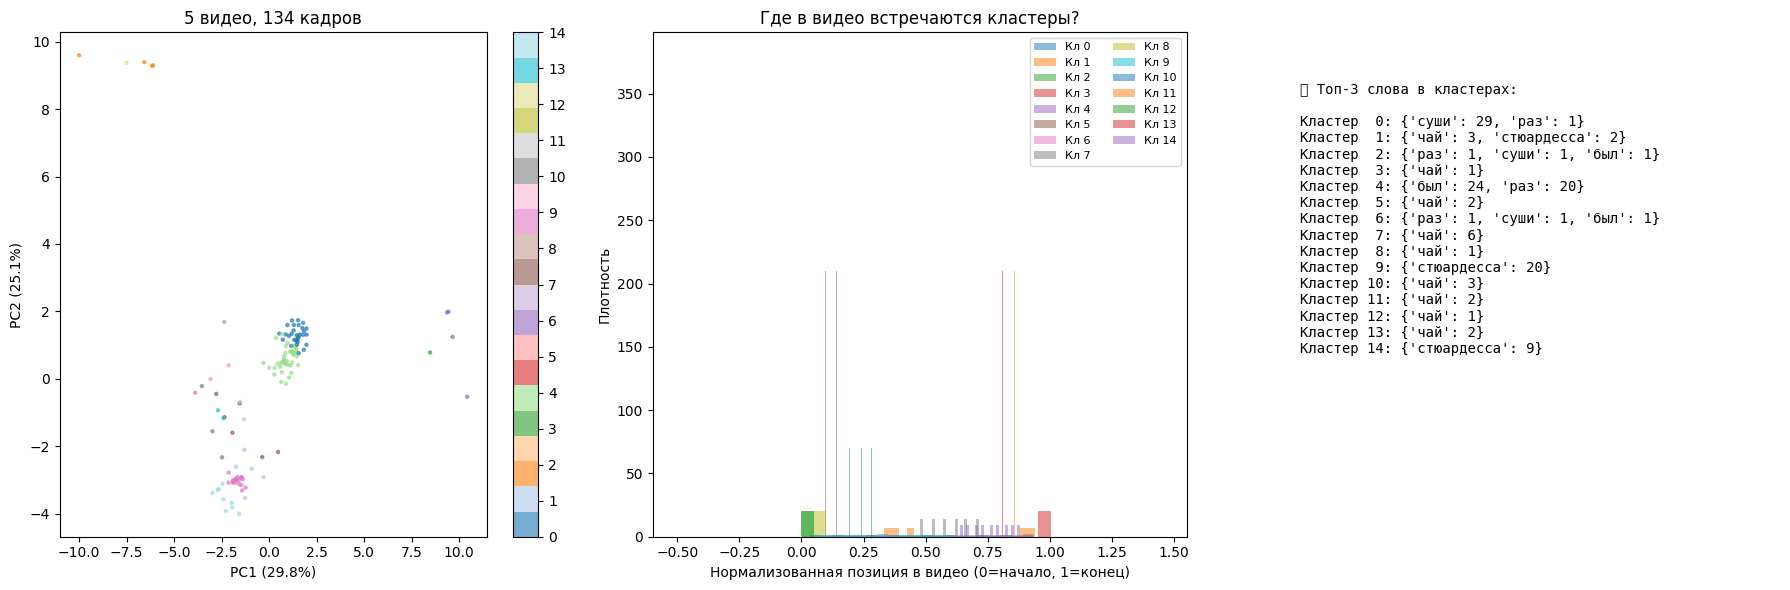


💡 Интерпретация:
   - ЛЕВЫЙ: кластеры в 2D
   - ЦЕНТР: если кластер встречается в начале/середине/конце видео — это дактилема перехода/удержания
   - ПРАВЫЙ: слова, попавшие в каждый кластер


In [53]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Собираем ВСЕ кадры из всех видео
all_frames = []
all_words = []
video_sources = []
frame_positions = []  # позиция кадра внутри видео (0..1)

for filename, data in all_embeddings.items():
    emb = data['embeddings']  # [T, 1024]
    word = data['word']
    T = data['num_frames']

    for i in range(T):
        all_frames.append(emb[i])
        all_words.append(word)
        video_sources.append(filename)
        frame_positions.append(i / T if T > 1 else 0)  # нормализованная позиция

X = np.stack(all_frames)
print(f"📊 Всего кадров из {len(all_embeddings)} видео: {X.shape[0]}")
print(f"   Размерность: {X.shape}")

# Кластеризация
n_clusters = 15
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X)

print(f"\n🏷️ Распределение по {n_clusters} кластерам:")
unique, counts = np.unique(labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"   Кластер {cluster}: {count} кадров ({count/len(labels)*100:.1f}%)")

# PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1: PCA по кластерам
scatter = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab20', s=5, alpha=0.6)
axes[0].set_title(f'{len(all_embeddings)} видео, {X.shape[0]} кадров')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(scatter, ax=axes[0], ticks=range(n_clusters))

# 2: Распределение позиций кадров по кластерам
for cluster in range(n_clusters):
    mask = labels == cluster
    positions_in_cluster = np.array(frame_positions)[mask]
    if len(positions_in_cluster) > 0:
        axes[1].hist(positions_in_cluster, bins=20, alpha=0.5, label=f'Кл {cluster}', density=True)
axes[1].set_xlabel('Нормализованная позиция в видео (0=начало, 1=конец)')
axes[1].set_ylabel('Плотность')
axes[1].set_title('Где в видео встречаются кластеры?')
axes[1].legend(loc='upper right', fontsize=8, ncol=2)

# 3: Топ-слов в кластерах (текст)
axes[2].axis('off')
cluster_words = {i: [] for i in range(n_clusters)}
for label, word in zip(labels, all_words):
    cluster_words[label].append(word)

text_summary = "📋 Топ-3 слова в кластерах:\n\n"
for cluster in range(n_clusters):
    words = cluster_words[cluster]
    if words:
        top = Counter(words).most_common(3)
        text_summary += f"Кластер {cluster:2d}: {dict(top)}\n"
axes[2].text(0.1, 0.9, text_summary, transform=axes[2].transAxes,
             fontsize=10, verticalalignment='top', fontfamily='monospace')

plt.tight_layout()
plt.show()

print("\n💡 Интерпретация:")
print("   - ЛЕВЫЙ: кластеры в 2D")
print("   - ЦЕНТР: если кластер встречается в начале/середине/конце видео — это дактилема перехода/удержания")
print("   - ПРАВЫЙ: слова, попавшие в каждый кластер")

# Извлечение выходов модели

In [26]:
from demo_KP.utils import getRuTokens
from src.utils.ctc_decoder import Decoder

text_decoder = Decoder(getRuTokens())
print(f"✅ Декодер в текст загружен!")

✅ Декодер в текст загружен!


In [27]:
from tqdm import tqdm

def sigmoid(a: np.ndarray):
    return 1 / (1 + np.exp(-a))

print("🎯 Извлекаем выходы модели для видео (ВСЕ кадры, без семплирования)...\n")

video_data = []

# Берём последние 5 видео для теста
for video_info in tqdm(found_videos[-5:]):
    out, length, success = apply_model_full(
        preprocess_frames(video_info['path']),
        model
    )

    if success:
        video_data.append({
            'filename': video_info['filename'],
            'word': video_info['word'],
            'path': video_info['path'],
            'output': out,
            'output_proba': sigmoid(out),
            'out_shape': out.shape,
            'num_frames': length
        })
        # print(f"  ✅ {video_info['filename']}: {length} кадров")

print(f"\n✅ Успешно обработано: {len(video_data)} видео")

if video_data:
    print("\n📊 Результаты:")
    for v in video_data:
        print(f"   {v['filename']}: {v['word']} → {v['num_frames']} кадров, выход {v['out_shape']}")
        print(f"       Жадно: {''.join(text_decoder.greedy_decode(v['output_proba']))}")
        print(f"       Beam-поиск (beam_size=4): {''.join(text_decoder.beam_decode(v['output_proba'], 4))}")

🎯 Извлекаем выходы модели для видео (ВСЕ кадры, без семплирования)...



100%|██████████| 5/5 [00:11<00:00,  2.37s/it]


✅ Успешно обработано: 5 видео

📊 Результаты:
   RSLN-b1-s64_08_ной.webm: ной → 25 кадров, выход (25, 35)
       Жадно: г
       Beam-поиск (beam_size=4): гбмбмбмбмб
   RSLN-n1-s26-d_01_виноград.webm: виноград → 45 кадров, выход (45, 35)
       Жадно: уб
       Beam-поиск (beam_size=4): уб
   RSLN-n1-s26-d_02_роста.webm: роста → 29 кадров, выход (29, 35)
       Жадно: уб
       Beam-поиск (beam_size=4): уб
   RSLN-n1-s26-d_03_сок.webm: сок → 40 кадров, выход (40, 35)
       Жадно: рпб
       Beam-поиск (beam_size=4): рпб
   RSLN-n1-s26-d_04_сорока_ворона.webm: сорока ворона → 64 кадров, выход (64, 35)
       Жадно: нпбп
       Beam-поиск (beam_size=4): нпбп
